# 最高到達accuracyを取得する

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import json
import re
import sys
from collections import defaultdict

project_root = os.path.join(os.getcwd(), "..")
result_dir = os.path.join(project_root, "results")


def load_file_and_extract_max_accs(date, model_size, result_dir):
    """各initVecTypeとseedに対して、回したepochs中の最高到達accuracyを抽出する関数"""
    dirname_pattern = f"gemma-3-{model_size}B-lr0.01-{date}_seed(\\d+)_target_concepts_initvecwith(.*)"

    initVecType_to_seed_to_maxacc = defaultdict(dict)
    initVecType_to_seed_to_epoch_at_maxacc = defaultdict(dict)
    for dirname in os.listdir(result_dir):
        if re.match(dirname_pattern, dirname):
            match_groups = re.search(dirname_pattern, dirname)
            seed = int(match_groups.group(1))
            initVecType = match_groups.group(2)
            if not os.path.exists(os.path.join(result_dir, dirname, 'logit_score_summary.json')):
                # print(f"Warning: logit_score_summary.json not found in {dirname}. Skipping.")
                continue
            with open(os.path.join(result_dir, dirname, 'logit_score_summary.json'), "r") as f:
                concept_to_epoch_to_scores = json.load(f)

            # 各conceptについて、回したepochs中の最高到達accuracyとそのepochを抽出
            max_accs = []
            epochs_at_maxacc = []
            for epoch_to_scores in concept_to_epoch_to_scores.values():
                max_accuracy = 0
                max_epoch_at_maxacc = 0
                for epoch, scores in epoch_to_scores.items():
                    # print(f"Epoch: {epoch}, Accuracy: {scores['accuracy']}")
                    if scores['accuracy'] > max_accuracy:
                        max_accuracy = scores['accuracy']
                        max_epoch_at_maxacc = epoch
                max_accs.append(max_accuracy)
                epochs_at_maxacc.append(max_epoch_at_maxacc)
            # print(f"Max Accuracies: {max_accs}")
            # print(f"Epochs at Max Accuracies: {epochs_at_maxacc}")
            initVecType_to_seed_to_maxacc[initVecType][seed] = max_accs
            initVecType_to_seed_to_epoch_at_maxacc[initVecType][seed] = epochs_at_maxacc
    return initVecType_to_seed_to_maxacc, initVecType_to_seed_to_epoch_at_maxacc


## 4B

In [ ]:

date = '20260316'
model_size = '4'

# dirname_pattern = f"gemma-3-{model_size}B-lr0.01-{date}_seed(\\d+)_target_concepts_initvecwith(.*)"


In [11]:

initVecType_to_seed_to_maxacc, initVecType_to_seed_to_epoch_at_maxacc = load_file_and_extract_max_accs(date, model_size, result_dir)

for initVecType, seed_to_maxacc in initVecType_to_seed_to_maxacc.items():
    for seed, max_accs in seed_to_maxacc.items():
        mean_max_acc = np.mean(max_accs)
        std_max_acc = np.std(max_accs)
        print(f"InitVecType: {initVecType:15}, Seed: {seed}, Mean Max Accuracy: {mean_max_acc:.4f}, Std: {std_max_acc:.4f}")
print()
for initVecType, seed_to_epoch_at_maxacc in initVecType_to_seed_to_epoch_at_maxacc.items():
    for seed, epochs_at_maxacc in seed_to_epoch_at_maxacc.items():
        mean_epoch_at_maxacc = np.mean([int(e) for e in epochs_at_maxacc])
        std_epoch_at_maxacc = np.std([int(e) for e in epochs_at_maxacc])
        print(f"InitVecType: {initVecType:15}, Seed: {seed}, Mean Epoch number at Max Accuracy: {mean_epoch_at_maxacc:.2f}, Std: {std_epoch_at_maxacc:.2f}")


InitVecType: category_centroid_plus_random, Seed: 0, Mean Max Accuracy: 0.4021, Std: 0.0877
InitVecType: norm_rand_vocab, Seed: 0, Mean Max Accuracy: 0.4067, Std: 0.0707

InitVecType: category_centroid_plus_random, Seed: 0, Mean Epoch number at Max Accuracy: 4.10, Std: 3.03
InitVecType: norm_rand_vocab, Seed: 0, Mean Epoch number at Max Accuracy: 3.90, Std: 2.45


## 12B

In [7]:

date = '20260317'
model_size = '12'

# dirname_pattern = f"gemma-3-{model_size}B-lr0.01-{date}_seed(\\d+)_target_concepts_initvecwith(.*)"


In [31]:

initVecType_to_seed_to_maxacc, initVecType_to_seed_to_epoch_at_maxacc = load_file_and_extract_max_accs(date, model_size, result_dir)

for initVecType, seed_to_maxacc in initVecType_to_seed_to_maxacc.items():
    for seed, max_accs in seed_to_maxacc.items():
        mean_max_acc = np.mean(max_accs)
        std_max_acc = np.std(max_accs)
        print(f"InitVecType: {initVecType:15}, Seed: {seed}, Mean Max Accuracy: {mean_max_acc:.4f}, Std: {std_max_acc:.4f}")
print()
for initVecType, seed_to_epoch_at_maxacc in initVecType_to_seed_to_epoch_at_maxacc.items():
    for seed, epochs_at_maxacc in seed_to_epoch_at_maxacc.items():
        mean_epoch_at_maxacc = np.mean([int(e) for e in epochs_at_maxacc])
        std_epoch_at_maxacc = np.std([int(e) for e in epochs_at_maxacc])
        print(f"InitVecType: {initVecType:15}, Seed: {seed}, Mean Epoch number at Max Accuracy: {mean_epoch_at_maxacc:.2f}, Std: {std_epoch_at_maxacc:.2f}")


InitVecType: uniform        , Seed: 0, Mean Max Accuracy: 0.4706, Std: 0.1435
InitVecType: other_category_COG, Seed: 0, Mean Max Accuracy: 0.4924, Std: 0.1408
InitVecType: norm_rand_vocab, Seed: 0, Mean Max Accuracy: 0.5076, Std: 0.1534
InitVecType: category_centroid_plus_random, Seed: 0, Mean Max Accuracy: 0.4893, Std: 0.1447

InitVecType: uniform        , Seed: 0, Mean Epoch number at Max Accuracy: 3.48, Std: 3.03
InitVecType: other_category_COG, Seed: 0, Mean Epoch number at Max Accuracy: 4.34, Std: 2.93
InitVecType: norm_rand_vocab, Seed: 0, Mean Epoch number at Max Accuracy: 3.51, Std: 2.91
InitVecType: category_centroid_plus_random, Seed: 0, Mean Epoch number at Max Accuracy: 3.81, Std: 2.95


In [5]:
not_show_initVecTypes = [
    'zero',
    'category_COG'
]

initVecType_to_seed_to_maxacc, initVecType_to_seed_to_epoch_at_maxacc = load_file_and_extract_max_accs(date, model_size, result_dir)

for initVecType, seed_to_maxacc in initVecType_to_seed_to_maxacc.items():
    if initVecType in not_show_initVecTypes:
        continue
    for seed, max_accs in seed_to_maxacc.items():
        mean_max_acc = np.mean(max_accs)
        std_max_acc = np.std(max_accs)
        print(f"InitVecType: {initVecType:15}, Seed: {seed}, Mean Max Accuracy: {mean_max_acc:.4f}, Std: {std_max_acc:.4f}")
print()
for initVecType, seed_to_epoch_at_maxacc in initVecType_to_seed_to_epoch_at_maxacc.items():
    if initVecType in not_show_initVecTypes:
        continue
    for seed, epochs_at_maxacc in seed_to_epoch_at_maxacc.items():
        mean_epoch_at_maxacc = np.mean([int(e) for e in epochs_at_maxacc])
        std_epoch_at_maxacc = np.std([int(e) for e in epochs_at_maxacc])
        print(f"InitVecType: {initVecType:15}, Seed: {seed}, Mean Epoch number at Max Accuracy: {mean_epoch_at_maxacc:.2f}, Std: {std_epoch_at_maxacc:.2f}")


InitVecType: other_category_COG, Seed: 0, Mean Max Accuracy: 0.4924, Std: 0.1408
InitVecType: category_centroid_plus_random, Seed: 0, Mean Max Accuracy: 0.4893, Std: 0.1447

InitVecType: other_category_COG, Seed: 0, Mean Epoch number at Max Accuracy: 4.34, Std: 2.93
InitVecType: category_centroid_plus_random, Seed: 0, Mean Epoch number at Max Accuracy: 3.81, Std: 2.95


In [23]:
for initVecType, seed_to_maxacc in initVecType_to_seed_to_maxacc.items():
    for seed, max_accs in seed_to_maxacc.items():
        print(f"InitVecType: {initVecType:15}, Seed: {seed}, Max Accuracies: {[round(acc, 2) for acc in max_accs]}")

InitVecType: category_COG   , Seed: 0, Max Accuracies: [0.35, 0.23, 0.58, 0.43, 0.58, 0.22, 0.24, 0.3, 0.42, 0.52, 0.23, 0.36, 0.5, 0.34, 0.35, 0.54, 0.37, 0.51, 0.54, 0.52, 0.51, 0.5, 0.54, 0.34, 0.36, 0.56, 0.31, 0.33, 0.44, 0.39, 0.68, 0.52, 0.43, 0.74, 0.32, 0.59, 0.48, 0.48, 0.78, 0.4, 0.39, 0.77, 0.3, 0.5, 0.34, 0.56, 0.44, 0.79, 0.31, 0.54, 0.33, 0.53, 0.68, 0.44, 0.45, 0.46, 0.51, 0.41, 0.37, 0.24, 0.37, 0.46, 0.71, 0.47, 0.55, 0.62, 0.47, 0.38, 0.66, 0.27, 0.36, 0.4, 0.55, 0.31, 0.45, 0.39, 0.44, 0.43, 0.36, 0.29, 0.4, 0.33, 0.75, 0.35, 0.49, 0.22, 0.56, 0.54, 0.4, 0.4, 0.53, 0.45, 0.52, 0.48, 0.36, 0.49, 0.25, 0.53, 0.33, 0.48]
InitVecType: other_category_COG, Seed: 0, Max Accuracies: [0.37, 0.26, 0.51, 0.4, 0.56, 0.41, 0.21, 0.27, 0.58, 0.6, 0.21, 0.33, 0.52, 0.34, 0.53, 0.41, 0.42, 0.41, 0.72, 0.67, 0.44, 0.43, 0.42, 0.34, 0.4, 0.59, 0.31, 0.28, 0.66, 0.3, 0.45, 0.48, 0.43, 0.67, 0.33, 0.56, 0.4, 0.43, 0.89, 0.51, 0.36, 0.57, 0.39, 0.47, 0.34, 0.33, 0.53, 0.61, 0.31, 0.62, 

### 固定epoch時点でのacc比較

In [27]:

epoch = 0

def load_file_and_extract_accs_at_epoch(date, model_size, result_dir, epoch):
    dirname_pattern = f"gemma-3-{model_size}B-lr0.01-{date}_seed(\\d+)_target_concepts_initvecwith(.*)"

    initVecType_to_seed_to_accs = defaultdict(dict)
    for dirname in os.listdir(result_dir):
        if re.match(dirname_pattern, dirname):
            match_groups = re.search(dirname_pattern, dirname)
            seed = int(match_groups.group(1))
            initVecType = match_groups.group(2)
            if not os.path.exists(os.path.join(result_dir, dirname, 'logit_score_summary.json')):
                # print(f"Warning: logit_score_summary.json not found in {dirname}. Skipping.")
                continue
            with open(os.path.join(result_dir, dirname, 'logit_score_summary.json'), "r") as f:
                concept_to_epoch_to_scores = json.load(f)
            initVecType_to_seed_to_accs[initVecType][seed] = [epoch_to_scores[str(epoch)]['accuracy'] for epoch_to_scores in concept_to_epoch_to_scores.values()]
    return initVecType_to_seed_to_accs

initVecType_to_seed_to_accs = load_file_and_extract_accs_at_epoch(date, model_size, result_dir, epoch)
initVecType_to_seed_to_accs

defaultdict(dict,
            {'other_category_COG': {0: [0.3548387096774194,
               0.2037037037037037,
               0.38661710037174724,
               0.32,
               0.5443037974683544,
               0.21374045801526717,
               0.19718309859154928,
               0.21739130434782608,
               0.3055555555555556,
               0.52,
               0.1968503937007874,
               0.26881720430107525,
               0.5,
               0.336734693877551,
               0.16129032258064516,
               0.302158273381295,
               0.3670886075949367,
               0.4126984126984127,
               0.4868421052631579,
               0.35443037974683544,
               0.30597014925373134,
               0.19327731092436976,
               0.41911764705882354,
               0.34444444444444444,
               0.1527777777777778,
               0.3225806451612903,
               0.3108108108108108,
               0.213768115942029,
            

In [30]:

# epoch = 0
epoch +=1
initVecType_to_seed_to_accs = load_file_and_extract_accs_at_epoch(date, model_size, result_dir, epoch)

for initVecType, seed_to_accs in initVecType_to_seed_to_accs.items():
    for seed, accs in seed_to_accs.items():
        mean_acc = np.mean(accs, axis=0)
        std_acc = np.std(accs, axis=0)
        print(f"InitVecType: {initVecType:15}, Seed: {seed}, Mean Accuracy at Epoch {epoch}: {mean_acc:.4f}, Std: {std_acc:.4f}")
        # plt.plot(accs, label=f"{initVecType} (seed={seed})")
    # accs = list(seed_to_accs.values())
    # mean_accs = np.mean(accs, axis=0)
    # std_accs = np.std(accs, axis=0)
    # plt.plot(mean_accs, label=initVecType)
    # plt.fill_between(range(len(mean_accs)), mean_accs - std_accs, mean_accs + std_accs, alpha=0.2)

InitVecType: other_category_COG, Seed: 0, Mean Accuracy at Epoch 2: 0.4161, Std: 0.1402
InitVecType: category_centroid_plus_random, Seed: 0, Mean Accuracy at Epoch 2: 0.4188, Std: 0.1534


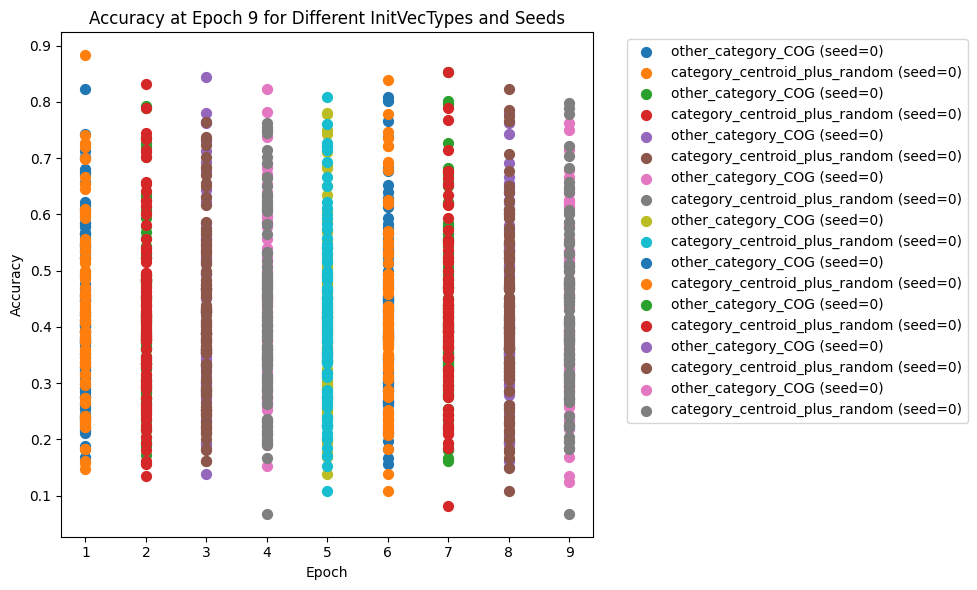

In [26]:
# initVecType_to_seed_to_accs を散布図で表示. x軸はepoch、y軸はaccuracy。点の色はinitVecType、点の形はseedで分ける
plt.figure(figsize=(10, 6))
markers = ['o', 's', 'D', '^', 'v', '<', '>']  # seedごとに異なるマーカーを用意
for epoch in range(1, 10):  # epoch 1から9まで
    initVecType_to_seed_to_accs = load_file_and_extract_accs_at_epoch(date, model_size, result_dir, epoch)
    for initVecType, seed_to_accs in initVecType_to_seed_to_accs.items():
        for seed, accs in seed_to_accs.items():
            plt.scatter([epoch] * len(accs), accs, label=f"{initVecType} (seed={seed})", marker=markers[seed % len(markers)], s=50)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Accuracy at Epoch {epoch} for Different InitVecTypes and Seeds")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### とりあえず全部線グラフにする

In [ ]:
epoch = 10
initVecType_to_epoch_to_accs = defaultdict(lambda: defaultdict(list))
for initVecType, seed_to_result in initVecType_to_results.items():
    for seed, result in seed_to_result.items():
        for 
        for epoch, scores in result.items():
            print(epoch, scores)
            # initVecType_to_epoch_to_accs[initVecType][epoch].append(scores['accuracy']) 
# initVecType_to_epoch_to_accs